# $B^\pm \to \pi^\pm\pi^+\pi^-$ — Jax-PWA gen-fit pull study **fitted in Square-Dalitz coordinates** (LHCb Run 1 isobar model)

Copy of `b2pipipi_cpvfit_toy_pull_study_SqDP.ipynb` that tests the Square-Dalitz fit option:
every toy is fitted with `CPFitSession(..., coordinates="square-dalitz")`, i.e. the events are
points of $(m', \theta')$ of the $\pi^+\pi^+$ pair (the models' `normalization_pair=(0, 1)`) and
the joint B+/B- density is per $dm'\,d\theta'$, normalized over the unit square. The toys are the
same as in the Dalitz-plot study (same model and seeds), and to exercise the Square-Dalitz input
path each toy is converted to $(m', \theta')$ and rebuilt with
`PhaseSpaceSample.from_square_dalitz` before the fit.

The Square-Dalitz Jacobian $|J|$ does not depend on the fit parameters, so

$$\mathrm{NLL}_{\rm SqDP}(\theta) = \mathrm{NLL}_{\rm DP}(\theta) - \sum_i \log|J_i| ,$$

and every toy must give the same fitted values and HESSE errors as in the Dalitz-plot study, with
an NLL lower by $\sum_i \log|J_i|$ (stored per toy as `log_jacobian_sum`). The last section
checks this toy by toy against the Dalitz-plot study's `RESULTS_CSV`.

---

*Original description:*

Generator-level gen-fit study done entirely inside Jax-PWA: **500 toys of 50 000 events each**
are generated from a fixed model, each toy is fitted back with the same model, and the fitted
parameters of every toy are stored. Pull distributions are built from the stored results.

## Model

The fixed model is the LHCb Run 1 isobar model of
[Phys. Rev. D 101, 012006 (2020)](https://arxiv.org/abs/1909.05212) (Table XXI CP-violating
Cartesian coefficients), in the same configuration already validated against Laura++ in
`paper_isobar_benchmark_squaredp_01_laura_toys.ipynb` (Laura++ `GenFit3pi.cc` conventions):

| component | lineshape | spin | mass, width [GeV] |
|---|---|---|---|
| `rho770` | Gounaris-Sakurai | 1 | 0.7708, 0.1534 (Table XX) |
| `omega782` | relativistic Breit-Wigner | 1 | 0.78265, 0.00849 |
| `f2_1270` | relativistic Breit-Wigner | 2 | 1.256, 0.1867 |
| `rho1450` | relativistic Breit-Wigner | 1 | 1.465, 0.400 |
| `rho3_1690` | relativistic Breit-Wigner | 3 | 1.686, 0.186 |
| `rescattering` | `PipiKKRescattering(convention="laura")` | 0 | 1.0-1.5 GeV window |
| `sigma` | `SigmaPole` | 0 | pole 0.563, 0.350 (Table XXII) |

All resonances use `pair=(2, 0)` (Laura++ `calcHelicities` orientation, symmetrized over the two
identical pions), Zemach angular factors and Blatt-Weisskopf radii of 4.0 GeV⁻¹. The coefficient
of charge $q=\pm1$ is $c_q = (x + q\,\delta x) + i\,(y + q\,\delta y)$; `rho770.x = 1`,
`rho770.y = 0` and `rho770.dy = 0` are fixed as the reference, the other 25 coefficients float.
Masses and widths are fixed. No local input files are read.

## Generation and fit

- **Pure signal**, generator level: no efficiency, no background, no veto.
- Toys are generated with `generate_cp_toy(..., method="accept-reject")` (exact sampling; the
  narrow `omega782` needs the large accept-reject pilot `TOY_POOL_SIZE`). The B+/B- split of each
  toy follows the model's integrated charge asymmetry.
- Each toy is fitted with `CPFitSession` (joint B+/B- normalization), starting from the true
  values, with HESSE uncertainties.
- Toys are **not** stored: each one is generated, fitted, and only its fitted parameters are
  written. Seeds are deterministic per toy (`SeedSequence([TOY_BASE_SEED, iexpt])`), so any toy
  can be regenerated exactly.

## Local caching

Everything lives in `CACHE_DIR` (`notebooks/validation/.cache/`, git-ignored):

1. the persistent JAX compilation cache, so a restarted kernel reuses the compiled toy
   generator. The NLL, gradient and Hessian programs embed each toy's events and can never be
   reused, so the loop deletes every cache entry a toy writes (other than the generator
   programs) and calls `jax.clear_caches()` after each toy to keep disk and RAM flat;
2. `RESULTS_CSV`, written after every toy. Toys already in the CSV are skipped, so the fit loop can
   be interrupted and resumed without losing work.

In [10]:
import os
from pathlib import Path

os.environ["JAX_PLATFORMS"] = "cuda"  # cpu, cuda, tpu
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

# Local cache root; set before JAX is imported so the persistent compilation cache is active
# from the first compiled program.
CACHE_DIR = Path(".cache/b2pipipi_lhcb_run1_genfit_squaredp_fit").resolve()
CACHE_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("JAX_COMPILATION_CACHE_DIR", str(CACHE_DIR / "jax_compilation"))
os.environ.setdefault("JAX_PERSISTENT_CACHE_MIN_COMPILE_TIME_SECS", "1.0")

'1.0'

In [11]:
import sys

for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / "src" / "jaxpwa").is_dir():
        sys.path.insert(0, str(candidate / "src"))
        break

import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

from jaxpwa import (
    CPFitSession,
    CPRealImag,
    PhaseSpaceSample,
    DecayChannel,
    DecayModel,
    GounarisSakurai,
    Parameter,
    PipiKKRescattering,
    RelativisticBreitWigner,
    Resonance,
    SigmaPole,
    ZemachP,
    enable_x64,
    generate_cp_toy,
    square_dalitz_log_jacobian,
)

enable_x64()

## Configuration

In [12]:
N_TOY_EVENTS = 50_000  # events per toy, B+ and B- together
N_EXPERIMENTS = 100
TOY_INDICES = range(N_EXPERIMENTS)  # narrow this (e.g. range(3)) for a quick smoke test
TOY_BASE_SEED = 1909052120  # toy iexpt uses SeedSequence([TOY_BASE_SEED, iexpt])
TOY_POOL_SIZE = 1_000_000  # accept-reject pilot; large enough to resolve omega(782)

NORMALIZATION_RESOLUTION = 1000  # Square-Dalitz (0, 1) quadrature, as in the benchmark notebook
FIT_STRATEGY = 1
FIT_NCALL = 100_000

FIT_COORDINATES = "square-dalitz"
RESULTS_CSV = CACHE_DIR / (
    f"results_n{N_TOY_EVENTS}_seed{TOY_BASE_SEED}_res{NORMALIZATION_RESOLUTION}_squaredp_fit.csv"
)
# Results of the Dalitz-plot study (same toys), for the toy-by-toy comparison at the end.
DALITZ_RESULTS_CSV = (
    CACHE_DIR.parent / "b2pipipi_lhcb_run1_genfit"
    / f"results_n{N_TOY_EVENTS}_seed{TOY_BASE_SEED}_res{NORMALIZATION_RESOLUTION}.csv"
)
print(f"results: {RESULTS_CSV}")

results: /data1000/juan/work/AnalisesEmAndamento/Run2/BKKK_Analysis/Jax-PWA/notebooks/validation/.cache/b2pipipi_lhcb_run1_genfit_squaredp_fit/results_n50000_seed1909052120_res1000_squaredp_fit.csv


## LHCb Run 1 isobar model

Masses/widths and Table XXI coefficients `(x, y, dx, dy)`, identical to
`paper_isobar_benchmark_squaredp_01_laura_toys.ipynb`. The rescattering term uses the Laura++
`LauRescatteringRes` defaults (`lambdaPiPi = 1.0`, `lambdaKK = 2.8`, hence
`delta_kk_squared = 2.8**2`).

In [13]:
MASS_WIDTHS = {
    "rho770": (0.7708, 0.1534),      # isobar fit, Table XX
    "omega782": (0.78265, 0.00849),  # Laura++/PDG
    "f2_1270": (1.256, 0.1867),      # isobar fit
    "rho1450": (1.465, 0.400),       # Laura++/PDG
    "rho3_1690": (1.686, 0.186),     # Laura++/PDG
    "sigma": (0.563, 0.350),         # fitted pole, Table XXII
}

# name: (x, y, dx, dy), Table XXI
COEFFICIENTS = {
    "rho770": (1.000, 0.000, -0.003, 0.000),
    "omega782": (0.091, -0.007, 0.000, -0.022),
    "f2_1270": (0.291, 0.204, -0.002, -0.179),
    "rho1450": (-0.223, 0.191, 0.031, 0.068),
    "rho3_1690": (0.073, -0.045, 0.044, -0.013),
    "rescattering": (0.142, -0.040, -0.047, -0.027),
    "sigma": (-0.485, 0.284, 0.231, 0.270),
}
FIXED_COEFFICIENTS = {"rho770.x", "rho770.y", "rho770.dy"}  # phase/magnitude reference

LINESHAPES = {
    "rho770": (GounarisSakurai, 1),
    "omega782": (RelativisticBreitWigner, 1),
    "f2_1270": (RelativisticBreitWigner, 2),
    "rho1450": (RelativisticBreitWigner, 1),
    "rho3_1690": (RelativisticBreitWigner, 3),
    "sigma": (SigmaPole, 0),
}

shared_coefficients = {}
TRUE_VALUES = {}
for name, values in COEFFICIENTS.items():
    pars = tuple(
        Parameter.coefficient(f"{name}.{axis}", value, owner=name, step=0.01,
                              fixed=f"{name}.{axis}" in FIXED_COEFFICIENTS)
        for axis, value in zip(("x", "y", "dx", "dy"), values, strict=True)
    )
    shared_coefficients[name] = CPRealImag(*pars)
    TRUE_VALUES.update({p.name: p.value for p in pars})


def build_components(charge):
    components = []
    for name in COEFFICIENTS:
        coefficient = shared_coefficients[name].for_charge(charge)
        if name == "rescattering":
            components.append(Resonance(
                name, (2, 0), coefficient,
                lineshape=PipiKKRescattering(convention="laura", delta_kk_squared=2.8**2),
                mass=1.0, width=0.0, spin=0, resonance_radius=4.0, parent_radius=4.0,
            ))
            continue
        lineshape, spin = LINESHAPES[name]
        mass, width = MASS_WIDTHS[name]
        components.append(Resonance(
            name, (2, 0), coefficient, lineshape=lineshape(), angular=ZemachP(),
            mass=mass, width=width, spin=spin, resonance_radius=4.0, parent_radius=4.0,
        ))
    return components


def build_model(charge):
    pion, other = ("pi+", "pi-") if charge > 0 else ("pi-", "pi+")
    return DecayModel(
        DecayChannel("B+" if charge > 0 else "B-", (pion, pion, other)),
        build_components(charge),
        normalize_components=True,
        normalization_method="square-dalitz",
        normalization_pair=(0, 1),
        normalization_resolution=NORMALIZATION_RESOLUTION,
    )


plus_model = build_model(+1)
minus_model = build_model(-1)
FREE_PARAMETER_NAMES = list(dict.fromkeys(
    p.name for p in plus_model.parameters + minus_model.parameters if not p.fixed
))
print("components:", [c.name for c in plus_model.amplitude_model.components])
print(f"free parameters: {len(FREE_PARAMETER_NAMES)}")

components: ['rho770', 'omega782', 'f2_1270', 'rho1450', 'rho3_1690', 'rescattering', 'sigma']
free parameters: 25


## Gen-fit loop

For each `iExpt`: generate one toy from the true model (accept-reject, deterministic seed), fit it
with `CPFitSession` starting from the true values, and append one row to `RESULTS_CSV` with the
fit status and the value and HESSE error of every free parameter. The toy itself is discarded.
Toys already in `RESULTS_CSV` are skipped; a toy whose generation or fit raises is reported and
skipped without stopping the loop (it is retried on the next run).

In [14]:
import gc

import jax


def release_toy_memory():
    """Free the host/device memory one toy leaves behind.

    Every toy builds a new CPFitSession and accept-reject density, i.e. new jitted closures.
    JAX keeps their traced programs and compiled executables in process-wide caches, so without
    this the kernel grows by ~80 MB per toy.
    """
    gc.collect()
    jax.clear_caches()
    gc.collect()


COMPILATION_CACHE_DIR = Path(os.environ["JAX_COMPILATION_CACHE_DIR"])
generator_programs_cached = False  # set once this kernel has kept the generator programs


def compilation_cache_entries():
    return set(COMPILATION_CACHE_DIR.iterdir()) if COMPILATION_CACHE_DIR.is_dir() else set()


def discard_new_cache_entries(kept):
    """Delete persistent-cache entries written since the snapshot `kept`.

    The fit programs (NLL/gradient, Hessian, prepared-cache kernels) embed the toy's events as
    constants, ~10 MB each, and the shuffle programs depend on the toy's B+/B- split, so no
    later toy or kernel can reuse them: without this the cache grows by ~20 MB per toy.
    """
    for entry in compilation_cache_entries() - kept:
        entry.unlink(missing_ok=True)


def toy_seed(iexpt):
    return int(np.random.SeedSequence([TOY_BASE_SEED, iexpt]).generate_state(1)[0])


def generate_toy(iexpt):
    return generate_cp_toy(
        plus_model, minus_model, N_TOY_EVENTS,
        parameters=TRUE_VALUES,
        method="accept-reject",
        pool_size=TOY_POOL_SIZE,
        include_momenta=False,
        seed=toy_seed(iexpt),
    )


def as_square_dalitz_input(sample, model):
    """Rebuild a toy from its (m', theta') coordinates, as Square-Dalitz input data would be."""
    kinematics = dict(
        mother_mass=float(model.channel.parent_mass),
        masses=tuple(float(m) for m in model.channel.daughter_masses),
        pair=tuple(model.normalization_pair),
    )
    mprime, thetaprime = sample.square_dalitz(**kinematics)
    return PhaseSpaceSample.from_square_dalitz(mprime, thetaprime, **kinematics)


def run_toy(iexpt):
    global generator_programs_cached
    cache_snapshot = compilation_cache_entries()
    try:
        t0 = time.perf_counter()
        plus_data, minus_data = generate_toy(iexpt)
        gen_time = time.perf_counter() - t0
        if not generator_programs_cached:
            # Keep what the first toy of this kernel compiled for the generator: those programs
            # are the same for every toy and are what a restarted kernel reloads.
            cache_snapshot = compilation_cache_entries()
            generator_programs_cached = True

        plus_data = as_square_dalitz_input(plus_data, plus_model)
        minus_data = as_square_dalitz_input(minus_data, minus_model)
        session = CPFitSession(plus_model, minus_model, plus_data, minus_data,
                               coordinates=FIT_COORDINATES)
        t0 = time.perf_counter()
        result = session.fit(
            dict(TRUE_VALUES), strategy=FIT_STRATEGY, ncall=FIT_NCALL,
            hesse=True, hessian="jax", verbose=0,
        )
        fit_time = time.perf_counter() - t0
    finally:
        discard_new_cache_entries(cache_snapshot)
    values = session.result_values(result)

    row = {
        "iExpt": iexpt,
        "seed": toy_seed(iexpt),
        "n_plus": plus_data.size,
        "n_minus": minus_data.size,
        "valid": bool(result.valid),
        "accurate_covariance": bool(result.fmin.has_accurate_covar),
        "nll": float(result.fval),
        "log_jacobian_sum": float(
            square_dalitz_log_jacobian(plus_model, plus_data).sum()
            + square_dalitz_log_jacobian(minus_model, minus_data).sum()
        ),
        "edm": float(result.fmin.edm),
        "nfcn": int(result.nfcn),
        "gen_time_s": gen_time,
        "fit_time_s": fit_time,
    }
    for name in FREE_PARAMETER_NAMES:
        row[name] = float(values[name])
        row[f"{name}_error"] = float(result.errors[name])
    return row


completed = (
    set(pd.read_csv(RESULTS_CSV)["iExpt"].astype(int)) if RESULTS_CSV.exists() else set()
)
pending = [i for i in TOY_INDICES if i not in completed]
print(f"{len(completed)} toys already fitted, {len(pending)} pending")

for iexpt in pending:
    try:
        row = run_toy(iexpt)
    except Exception as exc:  # keep the loop alive across a single bad toy
        print(f"iExpt={iexpt}: FAILED ({exc!r})")
        continue
    finally:
        release_toy_memory()
    pd.DataFrame([row]).to_csv(
        RESULTS_CSV, mode="a", header=not RESULTS_CSV.exists(), index=False
    )
    print(f"iExpt={iexpt}: valid={row['valid']} nll={row['nll']:.2f} "
          f"B+={row['n_plus']} B-={row['n_minus']} "
          f"(gen {row['gen_time_s']:.1f}s, fit {row['fit_time_s']:.1f}s)", flush=True)

2 toys already fitted, 98 pending
INFO Jax-PWA normalization: narrow resonance band(s) detected, but none is aligned with the selected Square-Dalitz mass pair; keeping the standard 1000 x 1000 grid.
INFO Jax-PWA normalization: narrow resonance band(s) detected, but none is aligned with the selected Square-Dalitz mass pair; keeping the standard 1000 x 1000 grid.
iExpt=2: valid=True nll=-16179.68 B+=23863 B-=26137 (gen 14.5s, fit 10.9s)
iExpt=3: valid=True nll=-15923.42 B+=23692 B-=26308 (gen 10.4s, fit 11.2s)
iExpt=4: valid=True nll=-15956.17 B+=23563 B-=26437 (gen 10.2s, fit 10.6s)
iExpt=5: valid=True nll=-15547.75 B+=23779 B-=26221 (gen 10.3s, fit 11.5s)
iExpt=6: valid=True nll=-16157.01 B+=23542 B-=26458 (gen 10.4s, fit 11.0s)
iExpt=7: valid=True nll=-15364.64 B+=23472 B-=26528 (gen 10.6s, fit 11.5s)
iExpt=8: valid=True nll=-15728.66 B+=23468 B-=26532 (gen 10.3s, fit 11.3s)
iExpt=9: valid=True nll=-15962.04 B+=23896 B-=26104 (gen 10.3s, fit 11.6s)
iExpt=10: valid=True nll=-15921.83 B

## Results: per-parameter distributions

`toy_results` collects every toy in `RESULTS_CSV`, including earlier runs of the loop. Only toys
with `valid=True` enter the pull statistics.

In [15]:
toy_results = pd.read_csv(RESULTS_CSV)
n_valid = int(toy_results["valid"].sum())
print(f"{len(toy_results)} toys fitted, {n_valid} with valid=True")

toy_results_valid = toy_results[toy_results["valid"]].copy()
for name in FREE_PARAMETER_NAMES:
    toy_results_valid[f"{name}_pull"] = (
        toy_results_valid[name] - TRUE_VALUES[name]
    ) / toy_results_valid[f"{name}_error"]

100 toys fitted, 100 with valid=True


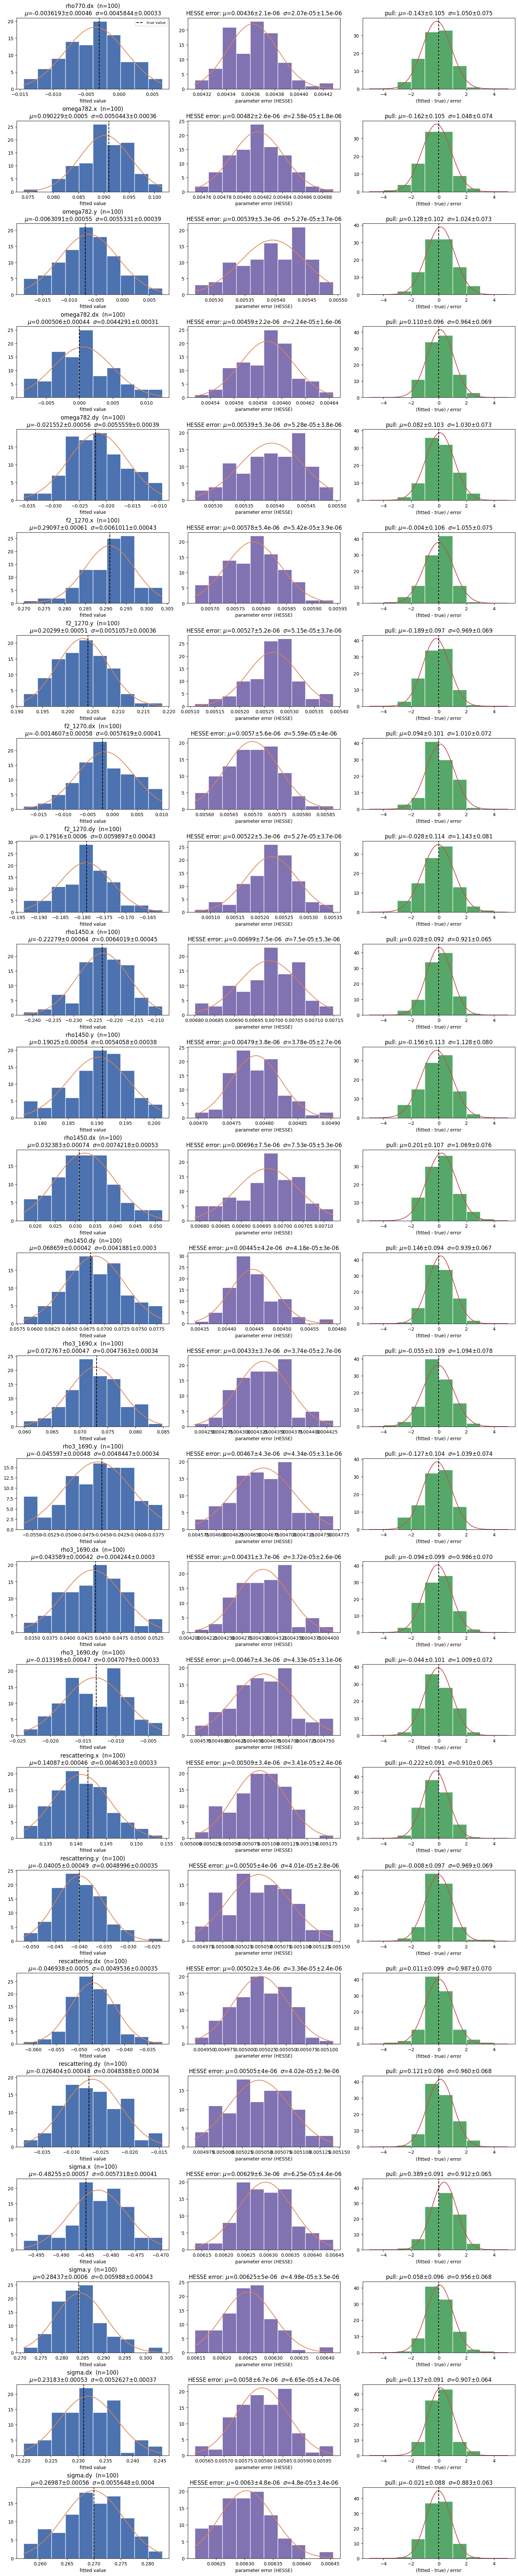

In [16]:
def _gaussian(x, amplitude, mu, sigma):
    return amplitude * np.exp(-0.5 * ((x - mu) / sigma) ** 2)


def histogram_bins(n):
    """Bin count that keeps bins populated for small ensembles (sqrt rule, 5..30 bins)."""
    return int(np.clip(np.sqrt(n), 5, 30))


def fit_gaussian(data, bins):
    """Unbinned Gaussian maximum-likelihood fit, i.e. the sample mean and standard deviation.

    Always defined (no minimizer that can fail on sparse histograms); the errors are the
    asymptotic ones, sigma/sqrt(n) for mu and sigma/sqrt(2(n-1)) for sigma. `amplitude` only
    scales the curve to the histogram drawn with `bins`.
    """
    data = np.asarray(data, dtype=float)
    data = data[np.isfinite(data)]
    n = data.size
    mu = data.mean()
    sigma = data.std(ddof=1) if n > 1 else 0.0
    counts, edges = np.histogram(data, bins=bins)
    width = edges[1] - edges[0]
    amplitude = n * width / (np.sqrt(2.0 * np.pi) * sigma) if sigma > 0 else counts.max()
    return {
        "amplitude": amplitude, "mu": mu, "sigma": sigma,
        "mu_error": sigma / np.sqrt(n) if n > 0 else np.nan,
        "sigma_error": sigma / np.sqrt(2.0 * (n - 1)) if n > 1 else np.nan,
    }, edges


GAUSSIAN_FITS = {}

fig, axes = plt.subplots(len(FREE_PARAMETER_NAMES), 3,
                         figsize=(15.5, 3.1 * len(FREE_PARAMETER_NAMES)), constrained_layout=True)

for row, name in enumerate(FREE_PARAMETER_NAMES):
    values = toy_results_valid[name].to_numpy()
    errors_ = toy_results_valid[f"{name}_error"].to_numpy()
    pulls = toy_results_valid[f"{name}_pull"].to_numpy()
    true_value = TRUE_VALUES[name]

    n_bins = histogram_bins(len(values))
    value_fit, value_edges = fit_gaussian(values, bins=n_bins)
    error_fit, error_edges = fit_gaussian(errors_, bins=n_bins)
    pull_fit, pull_edges = fit_gaussian(pulls, bins=np.linspace(-5, 5, n_bins + 1))
    GAUSSIAN_FITS[name] = {"value": value_fit, "error": error_fit, "pull": pull_fit}

    ax_val, ax_err, ax_pull = axes[row]
    ax_val.hist(values, bins=value_edges, color="#4C72B0", edgecolor="white")
    x_val = np.linspace(value_edges[0], value_edges[-1], 300)
    ax_val.plot(x_val, _gaussian(x_val, value_fit["amplitude"], value_fit["mu"], value_fit["sigma"]),
                color="#DD8452")
    ax_val.axvline(true_value, color="black", linestyle="--", label="true value")
    ax_val.set_title(
        f"{name}  (n={len(values)})\n"
        fr"$\mu$={value_fit['mu']:.5g}$\pm${value_fit['mu_error']:.2g}  "
        fr"$\sigma$={value_fit['sigma']:.5g}$\pm${value_fit['sigma_error']:.2g}"
    )
    ax_val.set_xlabel("fitted value")
    if row == 0:
        ax_val.legend(fontsize=8)

    ax_err.hist(errors_, bins=error_edges, color="#8172B2", edgecolor="white")
    x_err = np.linspace(error_edges[0], error_edges[-1], 300)
    ax_err.plot(x_err, _gaussian(x_err, error_fit["amplitude"], error_fit["mu"], error_fit["sigma"]),
                color="#DD8452")
    ax_err.set_title(
        fr"HESSE error: $\mu$={error_fit['mu']:.3g}$\pm${error_fit['mu_error']:.2g}  "
        fr"$\sigma$={error_fit['sigma']:.3g}$\pm${error_fit['sigma_error']:.2g}"
    )
    ax_err.set_xlabel("parameter error (HESSE)")

    ax_pull.hist(pulls, bins=pull_edges, color="#55A868", edgecolor="white")
    x_pull = np.linspace(pull_edges[0], pull_edges[-1], 300)
    ax_pull.plot(x_pull, _gaussian(x_pull, pull_fit["amplitude"], pull_fit["mu"], pull_fit["sigma"]),
                 color="#C44E52")
    ax_pull.axvline(0.0, color="black", linestyle="--")
    ax_pull.set_title(
        fr"pull: $\mu$={pull_fit['mu']:.3f}$\pm${pull_fit['mu_error']:.3f}  "
        fr"$\sigma$={pull_fit['sigma']:.3f}$\pm${pull_fit['sigma_error']:.3f}"
    )
    ax_pull.set_xlabel("(fitted - true) / error")

## Numerical summary

For each free parameter: the true generation value and the unbinned Gaussian-fit parameters (sample mean and
standard deviation, with their asymptotic uncertainties) of the fitted-value, HESSE-error and pull distributions. An unbiased fit
with correct uncertainties gives `pull_mu` close to 0 and `pull_sigma` close to 1.

In [17]:
summary_rows = []
for name in FREE_PARAMETER_NAMES:
    row = {"parameter": name, "true_value": TRUE_VALUES[name]}
    for kind in ("value", "error", "pull"):
        fit = GAUSSIAN_FITS[name][kind]
        row.update({
            f"{kind}_mu": fit["mu"], f"{kind}_mu_error": fit["mu_error"],
            f"{kind}_sigma": fit["sigma"], f"{kind}_sigma_error": fit["sigma_error"],
        })
    summary_rows.append(row)

pull_summary = pd.DataFrame(summary_rows).set_index("parameter")
pull_summary.to_csv(RESULTS_CSV.with_name(RESULTS_CSV.stem + "_pull_summary.csv"))
pull_summary

,true_value,value_mu,value_mu_error,value_sigma,value_sigma_error,error_mu,error_mu_error,error_sigma,error_sigma_error,pull_mu,pull_mu_error,pull_sigma,pull_sigma_error
parameter,,,,,,,,,,,,,
rho770.dx,-0.003,-0.003619,0.000458,0.004584,0.000326,0.004362,0.000002,0.000021,0.000001,-0.142555,0.105017,1.050169,0.074632
omega782.x,0.091,0.090229,0.000504,0.005044,0.000358,0.004816,0.000003,0.000026,0.000002,-0.162404,0.104771,1.047713,0.074458
omega782.y,-0.007,-0.006309,0.000553,0.005533,0.000393,0.005395,0.000005,0.000053,0.000004,0.128500,0.102441,1.024406,0.072801
omega782.dx,0.000,0.000506,0.000443,0.004429,0.000315,0.004588,0.000002,0.000022,0.000002,0.110249,0.096417,0.964173,0.068521
omega782.dy,-0.022,-0.021552,0.000556,0.005556,0.000395,0.005395,0.000005,0.000053,0.000004,0.082101,0.103036,1.030356,0.073224
f2_1270.x,0.291,0.290973,0.000610,0.006101,0.000434,0.005785,0.000005,0.000054,0.000004,-0.003702,0.105528,1.055279,0.074995
f2_1270.y,0.204,0.202994,0.000511,0.005106,0.000363,0.005267,0.000005,0.000052,0.000004,-0.189475,0.096948,0.969480,0.068898
f2_1270.dx,-0.002,-0.001461,0.000576,0.005762,0.000409,0.005699,0.000006,0.000056,0.000004,0.093764,0.101024,1.010243,0.071795
f2_1270.dy,-0.179,-0.179157,0.000599,0.005990,0.000426,0.005224,0.000005,0.000053,0.000004,-0.028113,0.114330,1.143297,0.081251


## Toy-by-toy comparison with the Dalitz-plot fit

Same toys (seeds) as `b2pipipi_cpvfit_toy_pull_study_SqDP.ipynb`. For every toy fitted in both
studies: the largest difference of fitted value and HESSE error in units of the Dalitz-plot HESSE
error, and $\mathrm{NLL}_{\rm DP} - \mathrm{NLL}_{\rm SqDP} - \sum_i \log|J_i|$, which must vanish.
Residual differences come only from where Minuit stops (tolerance/EDM) and from the
$(m', \theta')$ round trip of the events, both far below the statistical errors.

100 toys in both studies, 100 valid in both
                                       mean           std           max
max |value diff| / DP error    7.791451e-08  8.014320e-08  3.761450e-07
max |error ratio - 1|          5.407495e-10  9.670242e-10  9.076365e-09
NLL_DP - NLL_SqDP - sum log J  3.783498e-11  4.779563e-11  1.746230e-10


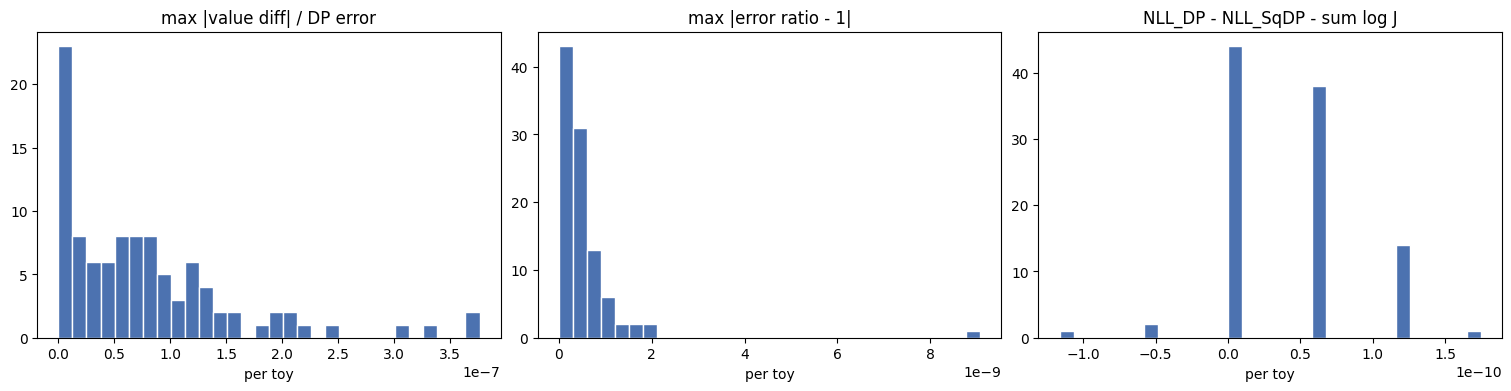

In [18]:
if not DALITZ_RESULTS_CSV.exists():
    print(f"Dalitz-plot results not found: {DALITZ_RESULTS_CSV}")
else:
    dalitz = pd.read_csv(DALITZ_RESULTS_CSV).set_index("iExpt")
    square = pd.read_csv(RESULTS_CSV).set_index("iExpt")
    common = dalitz.index.intersection(square.index)
    both_valid = common[dalitz.loc[common, "valid"].to_numpy() & square.loc[common, "valid"].to_numpy()]
    print(f"{len(common)} toys in both studies, {len(both_valid)} valid in both")
    d, s = dalitz.loc[both_valid], square.loc[both_valid]

    value_shift = pd.DataFrame({
        name: (s[name] - d[name]) / d[f"{name}_error"] for name in FREE_PARAMETER_NAMES
    })
    error_ratio = pd.DataFrame({
        name: s[f"{name}_error"] / d[f"{name}_error"] - 1.0 for name in FREE_PARAMETER_NAMES
    })
    nll_check = d["nll"] - s["nll"] - s["log_jacobian_sum"]

    comparison = pd.DataFrame({
        "max |value diff| / DP error": value_shift.abs().max(axis=1),
        "max |error ratio - 1|": error_ratio.abs().max(axis=1),
        "NLL_DP - NLL_SqDP - sum log J": nll_check,
    })
    print(comparison.describe().T[["mean", "std", "max"]])

    fig, axes = plt.subplots(1, 3, figsize=(15, 3.8), constrained_layout=True)
    for ax, column in zip(axes, comparison.columns, strict=True):
        ax.hist(comparison[column], bins=30, color="#4C72B0", edgecolor="white")
        ax.set_title(column)
        ax.set_xlabel("per toy")
    plt.show()

    per_parameter = pd.DataFrame({
        "max |value diff| / DP error": value_shift.abs().max(),
        "max |error ratio - 1|": error_ratio.abs().max(),
    })
    per_parameter